# What Does AI Think About Singapore Restaurants?

**A systematic audit of LLM-mediated restaurant discovery**

We asked four leading AI models — GPT-4o, Claude Sonnet, Gemini 2.5 Flash, and Perplexity Sonar — 140 restaurant discovery prompts about Singapore dining, both with and without web search. Then we parsed, deduplicated, and ground-truthed their responses against Google Places.

This notebook presents the findings: what the models agree on, where they diverge, how stable their recommendations are, and how many of the restaurants they recommend are actually still open.

---

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import sqlite3
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import combinations
from scipy import stats

# Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_colwidth', 50)

# ── Consistent color palette ─────────────────────────────────────────────────
MODEL_COLORS = {
    'openai/gpt-4o': '#2ca02c',                      # green
    'anthropic/claude-sonnet-4-20250514': '#ff7f0e',  # orange
    'google/gemini-2.5-flash': '#1f77b4',             # blue
    'perplexity/sonar': '#9467bd',                    # purple
}
MODEL_SHORT = {
    'openai/gpt-4o': 'GPT-4o',
    'anthropic/claude-sonnet-4-20250514': 'Claude',
    'google/gemini-2.5-flash': 'Gemini',
    'perplexity/sonar': 'Perplexity',
}
MODEL_ORDER = ['openai/gpt-4o', 'anthropic/claude-sonnet-4-20250514',
               'google/gemini-2.5-flash', 'perplexity/sonar']

# ── Database connection ──────────────────────────────────────────────────────
DB_PATH = Path('..') / 'data' / 'aeo.db'
assert DB_PATH.exists(), f"Database not found at {DB_PATH}"
conn = sqlite3.connect(str(DB_PATH))

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

def model_short(name):
    """Convert full model name to display label."""
    return MODEL_SHORT.get(name, name)

def model_color(name):
    """Get the assigned color for a model."""
    return MODEL_COLORS.get(name, '#999999')

fig_num = 0
def next_fig():
    """Increment and return the current figure number."""
    global fig_num
    fig_num += 1
    return fig_num

print(f"Connected to {DB_PATH} — {DB_PATH.stat().st_size / 1e6:.1f} MB")

Connected to ../data/aeo.db — 11.1 MB


---

## Section 0 — Dataset Overview

Before any analysis, let's establish what we collected.

In [2]:
# ── Core dataset counts ──────────────────────────────────────────────────────
counts = {}

counts['prompts'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM discovery_prompts", conn
).iloc[0, 0]

counts['queries_total'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM query_results", conn
).iloc[0, 0]

counts['queries_main'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM query_results WHERE is_stability_test = 0", conn
).iloc[0, 0]

counts['queries_stability'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM query_results WHERE is_stability_test = 1", conn
).iloc[0, 0]

counts['mentions'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM restaurant_mentions", conn
).iloc[0, 0]

counts['canonical_total'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM canonical_restaurants", conn
).iloc[0, 0]

counts['canonical_active'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM canonical_restaurants WHERE model_count > 0", conn
).iloc[0, 0]

counts['google_verified'] = pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM google_places WHERE human_verified = 1", conn
).iloc[0, 0]

print("═" * 60)
print("  SG RESTAURANT AEO — DATASET SUMMARY")
print("═" * 60)
print(f"  Prompts:                 {counts['prompts']:>6,}")
print(f"  Models:                  {len(MODEL_ORDER):>6}")
print(f"  Queries (main sweep):    {counts['queries_main']:>6,}  (140 × 4 models × 2 search modes)")
print(f"  Queries (stability):     {counts['queries_stability']:>6,}  (15 × 4 models × 2 modes × 5 runs)")
print(f"  Queries (total):         {counts['queries_total']:>6,}")
print(f"  ─────────────────────────────────────")
print(f"  Restaurant mentions:     {counts['mentions']:>6,}")
print(f"  Canonical restaurants:   {counts['canonical_total']:>6,}  (total after entity resolution)")
print(f"  Active research set:     {counts['canonical_active']:>6,}  (model_count > 0)")
print(f"  Stability-only entries:  {counts['canonical_total'] - counts['canonical_active']:>6,}  (model_count = 0, excluded from most analyses)")
print(f"  Google Places verified:  {counts['google_verified']:>6,}")
print("═" * 60)

════════════════════════════════════════════════════════════
  SG RESTAURANT AEO — DATASET SUMMARY
════════════════════════════════════════════════════════════
  Prompts:                    140
  Models:                       4
  Queries (main sweep):     1,120  (140 × 4 models × 2 search modes)
  Queries (stability):        570  (15 × 4 models × 2 modes × 5 runs)
  Queries (total):          1,690
  ─────────────────────────────────────
  Restaurant mentions:     12,256
  Canonical restaurants:    3,666  (total after entity resolution)
  Active research set:      2,991  (model_count > 0)
  Stability-only entries:     675  (model_count = 0, excluded from most analyses)
  Google Places verified:   1,266
════════════════════════════════════════════════════════════


**Denominator convention:** The database contains 3,666 canonical restaurants, but 675 of these appeared *only* during stability reruns (Phase 2c) and have `model_count = 0` — they were never mentioned in the main 1,120-query sweep. Unless stated otherwise, all analyses below filter to the **2,991 active research set** (`model_count > 0`). The 675 stability-only entries are used exclusively in Section 5.

In [3]:
# ── Summary table: queries and mentions by model × search mode ────────────
summary = pd.read_sql_query("""
    SELECT
        qr.model_name,
        qr.search_enabled,
        COUNT(DISTINCT qr.id) AS queries,
        COUNT(rm.id) AS mentions,
        COUNT(DISTINCT rm.canonical_id) AS unique_restaurants,
        ROUND(CAST(COUNT(rm.id) AS FLOAT) / COUNT(DISTINCT qr.id), 1) AS avg_per_response
    FROM query_results qr
    LEFT JOIN parsed_responses pr ON pr.query_result_id = qr.id
    LEFT JOIN restaurant_mentions rm ON rm.parsed_response_id = pr.id
    WHERE qr.is_stability_test = 0
    GROUP BY qr.model_name, qr.search_enabled
    ORDER BY qr.model_name, qr.search_enabled
""", conn)

summary['model'] = summary['model_name'].map(model_short)
summary['search'] = summary['search_enabled'].map({0: 'OFF', 1: 'ON'})

display_cols = ['model', 'search', 'queries', 'mentions', 'unique_restaurants', 'avg_per_response']
print("Table 1 — Main sweep: queries and mentions by model × search mode")
summary[display_cols].style.set_properties(**{'text-align': 'right'})

Table 1 — Main sweep: queries and mentions by model × search mode


,model,search,queries,mentions,unique_restaurants,avg_per_response
0,Claude,OFF,140,971,490,6.900000
1,Claude,ON,140,1009,756,7.200000
2,Gemini,OFF,140,1107,671,7.900000
3,Gemini,ON,140,1656,1193,11.800000
4,GPT-4o,OFF,140,789,440,5.600000
5,GPT-4o,ON,140,746,414,5.300000
6,Perplexity,OFF,140,868,669,6.200000
7,Perplexity,ON,140,747,469,5.300000


The main sweep ran 140 prompts × 4 models × 2 search modes = 1,120 queries. Key things to note:

- **Gemini** is by far the most verbose, producing ~11 restaurant mentions per response vs GPT-4o's ~5.5
- **Search ON** generally increases the number of unique restaurants surfaced
- Across all conditions, we captured **~12,000 restaurant mentions** that resolved to **~2,991 unique canonical restaurants**

---

## Section 1 — The AI Restaurant Canon

Do the models agree on which restaurants matter? We find a tiny consensus core and an enormous long tail.

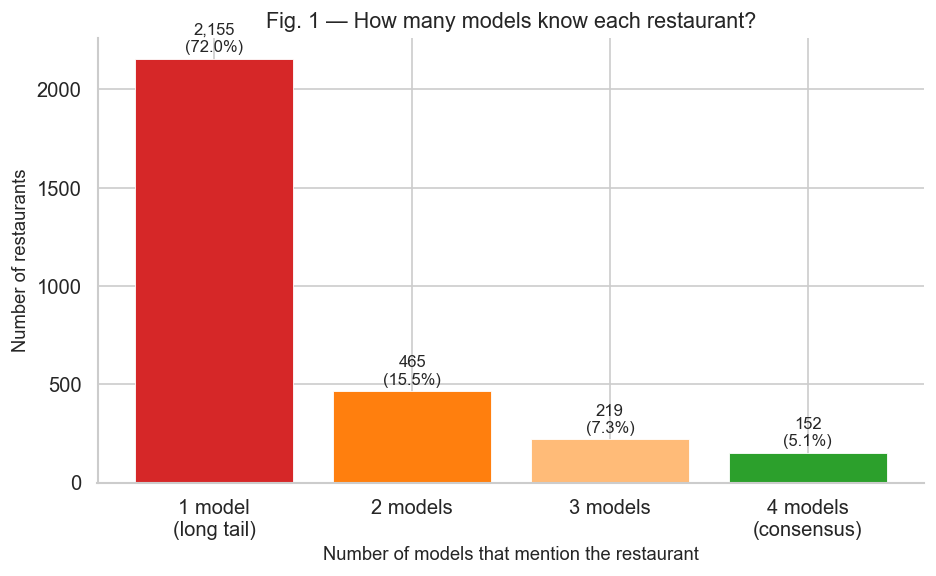


Consensus restaurants (all 4 models): 152 (5.1%)
Single-model restaurants (long tail):  2155 (72.0%)


In [4]:
# ── Fig. 1: Distribution of restaurants by how many models mention them ─────
model_dist = pd.read_sql_query("""
    SELECT model_count, COUNT(*) AS restaurants
    FROM canonical_restaurants
    WHERE model_count > 0
    GROUP BY model_count
    ORDER BY model_count
""", conn)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728', '#ff7f0e', '#ffbb78', '#2ca02c']
bars = ax.bar(model_dist['model_count'], model_dist['restaurants'], color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, model_dist['restaurants']):
    pct = val / model_dist['restaurants'].sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Number of models that mention the restaurant')
ax.set_ylabel('Number of restaurants')
ax.set_title(f'Fig. {next_fig()} — How many models know each restaurant?')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['1 model\n(long tail)', '2 models', '3 models', '4 models\n(consensus)'])
sns.despine()
plt.tight_layout()
plt.show()

consensus_n = model_dist.loc[model_dist['model_count'] == 4, 'restaurants'].values[0]
single_n = model_dist.loc[model_dist['model_count'] == 1, 'restaurants'].values[0]
total_active = model_dist['restaurants'].sum()
print(f"\nConsensus restaurants (all 4 models): {consensus_n} ({consensus_n/total_active*100:.1f}%)")
print(f"Single-model restaurants (long tail):  {single_n} ({single_n/total_active*100:.1f}%)")

The long tail dominates. Over 70% of restaurants are mentioned by only one model — they exist in that model's knowledge but nowhere else. The ~5% consensus set represents the "AI restaurant canon" — places with enough English-language media coverage to appear in every model's training data.

In [5]:
# ── Table 2: Top 30 consensus restaurants ────────────────────────────────────
top30 = pd.read_sql_query("""
    SELECT canonical_name, total_mentions, model_count, models_mentioning
    FROM canonical_restaurants
    WHERE model_count = 4
    ORDER BY total_mentions DESC
    LIMIT 30
""", conn)

top30.index = range(1, len(top30) + 1)
top30.index.name = 'Rank'
top30 = top30.rename(columns={
    'canonical_name': 'Restaurant',
    'total_mentions': 'Total Mentions',
    'model_count': 'Models'
})
top30 = top30.drop(columns=['models_mentioning'])

print(f"Table 2 — Top 30 consensus restaurants (mentioned by all 4 models)")
top30

Table 2 — Top 30 consensus restaurants (mentioned by all 4 models)


,Restaurant,Total Mentions,Models
Rank,,,
1,Odette,100,4
2,Burnt Ends,98,4
3,PS.Cafe,95,4
4,Violet Oon Singapore,71,4
5,Tian Tian Hainanese Chicken Rice,70,4
6,Meta Restaurant,68,4
7,Zen,68,4
8,Candlenut,63,4
9,Lau Pa Sat,63,4


Odette (100 mentions) and Burnt Ends (98) lead by a wide margin. The top of this list reads like Singapore's Michelin guide — fine dining and acclaimed hawker stalls that dominate food media. Note PS.Cafe at #3 with 95 mentions: it's not Michelin-starred, but it's *everywhere* in lifestyle media, showing that media saturation matters as much as culinary prestige.

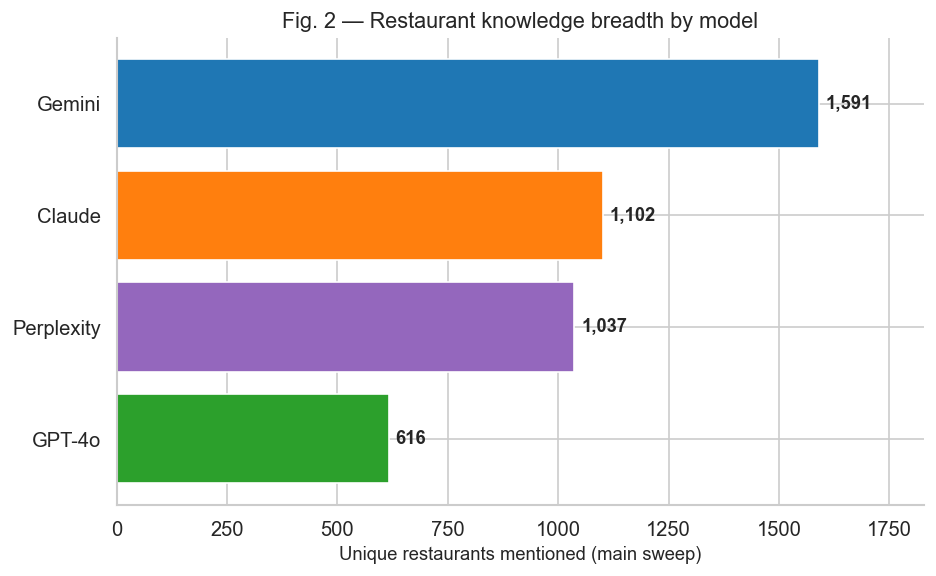


Gemini knows 2.6× more restaurants than GPT-4o (1,591 vs 616)


In [6]:
# ── Fig. 2: Per-model unique restaurant count ────────────────────────────────
per_model = pd.read_sql_query("""
    SELECT qr.model_name, COUNT(DISTINCT rm.canonical_id) AS unique_restaurants
    FROM restaurant_mentions rm
    JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
    JOIN query_results qr ON pr.query_result_id = qr.id
    WHERE qr.is_stability_test = 0 AND rm.canonical_id IS NOT NULL
    GROUP BY qr.model_name
    ORDER BY unique_restaurants DESC
""", conn)

fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = [model_color(m) for m in per_model['model_name']]
bars = ax.barh(
    [model_short(m) for m in per_model['model_name']],
    per_model['unique_restaurants'],
    color=bar_colors, edgecolor='white'
)
for bar, val in zip(bars, per_model['unique_restaurants']):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Unique restaurants mentioned (main sweep)')
ax.set_title(f'Fig. {next_fig()} — Restaurant knowledge breadth by model')
ax.set_xlim(0, per_model['unique_restaurants'].max() * 1.15)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

gemini_n = per_model.loc[per_model['model_name'] == 'google/gemini-2.5-flash', 'unique_restaurants'].values[0]
gpt_n = per_model.loc[per_model['model_name'] == 'openai/gpt-4o', 'unique_restaurants'].values[0]
print(f"\nGemini knows {gemini_n/gpt_n:.1f}× more restaurants than GPT-4o ({gemini_n:,} vs {gpt_n:,})")

Gemini's knowledge breadth is striking — it surfaces 2.5× more unique restaurants than GPT-4o. This is partly a verbosity effect (Gemini lists ~11 restaurants per response vs GPT-4o's ~5.5), but it also reflects genuine differences in training data coverage. For a lesser-known restaurant, being in Gemini's knowledge base is table stakes; being in GPT-4o's curated list is the prize.

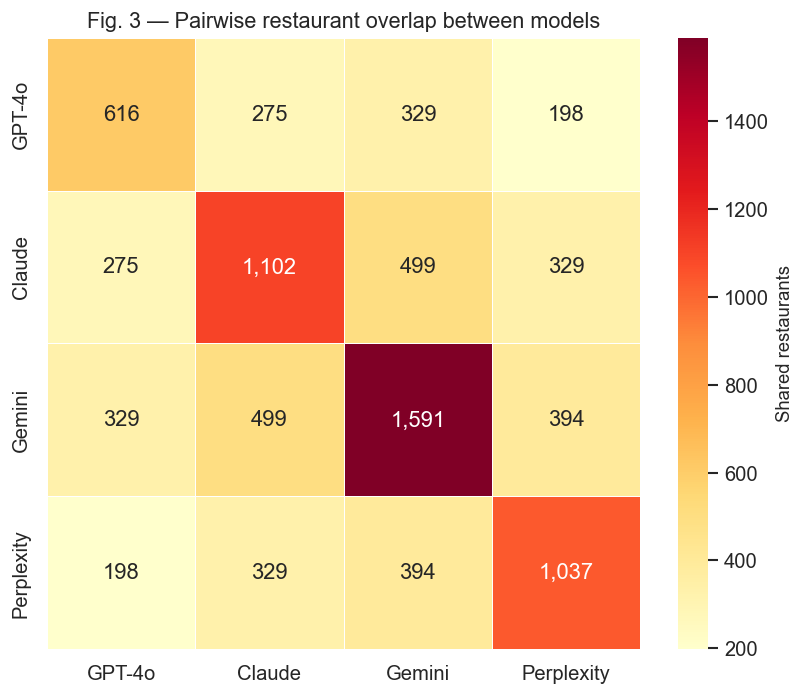

Diagonal = total unique restaurants per model.
Off-diagonal = restaurants shared between that pair.


In [7]:
# ── Fig. 3: Pairwise model overlap heatmap ───────────────────────────────────
# Get per-model restaurant sets
model_sets_df = pd.read_sql_query("""
    SELECT DISTINCT qr.model_name, rm.canonical_id
    FROM restaurant_mentions rm
    JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
    JOIN query_results qr ON pr.query_result_id = qr.id
    WHERE qr.is_stability_test = 0 AND rm.canonical_id IS NOT NULL
""", conn)

model_sets = {}
for m in MODEL_ORDER:
    model_sets[m] = set(model_sets_df.loc[model_sets_df['model_name'] == m, 'canonical_id'])

# Build overlap matrix
labels = [model_short(m) for m in MODEL_ORDER]
n = len(MODEL_ORDER)
overlap_matrix = np.zeros((n, n), dtype=int)
for i, m1 in enumerate(MODEL_ORDER):
    for j, m2 in enumerate(MODEL_ORDER):
        overlap_matrix[i, j] = len(model_sets[m1] & model_sets[m2])

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.zeros_like(overlap_matrix, dtype=bool)
# Show full matrix (diagonal = total per model)
sns.heatmap(overlap_matrix, annot=True, fmt=',', cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels, ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Shared restaurants'})
ax.set_title(f'Fig. {next_fig()} — Pairwise restaurant overlap between models')
plt.tight_layout()
plt.show()

print("Diagonal = total unique restaurants per model.")
print("Off-diagonal = restaurants shared between that pair.")

Claude and Gemini share the most restaurants (~499), while GPT-4o and Perplexity share the fewest (~198). The diagonal confirms the breadth hierarchy: Gemini > Claude > Perplexity > GPT-4o. The off-diagonal values show that even the most overlapping pair (Claude–Gemini) shares less than a third of Gemini's total — each model has substantial exclusive knowledge.

---

## Section 2 — Model Personalities

Each model doesn't just recommend *different* restaurants — it recommends them in characteristically different ways.

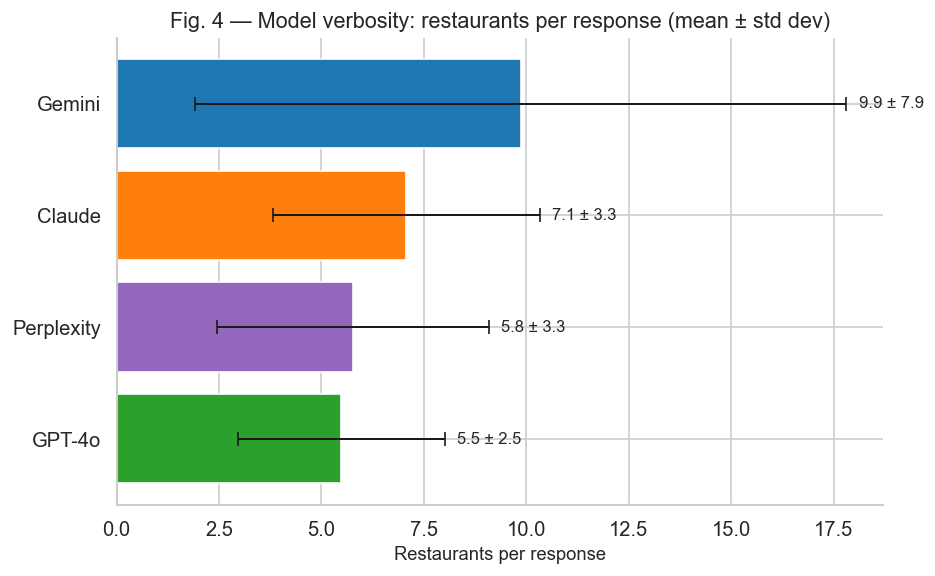

In [8]:
# ── Fig. 4: Average restaurants per response by model (with std dev) ──────
verbosity = pd.read_sql_query("""
    SELECT qr.model_name, qr.id AS query_id, COUNT(rm.id) AS n_mentions
    FROM query_results qr
    JOIN parsed_responses pr ON pr.query_result_id = qr.id
    LEFT JOIN restaurant_mentions rm ON rm.parsed_response_id = pr.id
    WHERE qr.is_stability_test = 0
    GROUP BY qr.id
""", conn)

verb_stats = verbosity.groupby('model_name')['n_mentions'].agg(['mean', 'std']).reset_index()
verb_stats = verb_stats.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(verb_stats))
bar_colors = [model_color(m) for m in verb_stats['model_name']]
bars = ax.barh(y_pos, verb_stats['mean'], xerr=verb_stats['std'],
               color=bar_colors, edgecolor='white', capsize=4, error_kw={'linewidth': 1.2})
ax.set_yticks(y_pos)
ax.set_yticklabels([model_short(m) for m in verb_stats['model_name']])
for bar, mean, std in zip(bars, verb_stats['mean'], verb_stats['std']):
    ax.text(bar.get_width() + std + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{mean:.1f} ± {std:.1f}', va='center', fontsize=10)

ax.set_xlabel('Restaurants per response')
ax.set_title(f'Fig. {next_fig()} — Model verbosity: restaurants per response (mean ± std dev)')
sns.despine()
plt.tight_layout()
plt.show()

Gemini's long lists (~11 per response) vs GPT-4o's short curation (~5.5) is the defining personality difference. This isn't about quality — it's about *strategy*. Gemini casts a wide net; GPT-4o picks favorites. For AEO, this means a mention from GPT-4o carries more "selection weight" than one from Gemini.

In [9]:
# ── Table 3: Model-exclusive restaurants (5+ mentions from only 1 model) ────
exclusives = pd.read_sql_query("""
    SELECT
        cr.canonical_name AS restaurant,
        cr.total_mentions AS mentions,
        cr.models_mentioning AS model_raw
    FROM canonical_restaurants cr
    WHERE cr.model_count = 1 AND cr.total_mentions >= 5
    ORDER BY cr.total_mentions DESC
""", conn)

# Parse the model name from the JSON list
exclusives['model'] = exclusives['model_raw'].apply(
    lambda x: model_short(json.loads(x)[0]) if x and x != '[]' else 'Unknown'
)
exclusives = exclusives.drop(columns=['model_raw'])

print(f"Table 3 — Model-exclusive restaurants (≥5 mentions, known to only 1 model)")
print(f"{'Restaurant':<35} {'Mentions':>8}  {'Exclusive to':>12}")
print("─" * 60)
for _, row in exclusives.head(20).iterrows():
    print(f"{row['restaurant']:<35} {row['mentions']:>8}  {row['model']:>12}")

# Count exclusives by model
excl_by_model = exclusives['model'].value_counts()
print(f"\nTotal exclusive restaurants (≥5 mentions): {len(exclusives)}")
print(f"By model: {dict(excl_by_model)}")

Table 3 — Model-exclusive restaurants (≥5 mentions, known to only 1 model)
Restaurant                          Mentions  Exclusive to
────────────────────────────────────────────────────────────
The Black Swan                             8        GPT-4o
Casa Vostra                                5    Perplexity
Founder Bak Kut Teh                        5        Gemini
Jag                                        5        Claude
PS.Cafe at Ann Siang Hill                  5        GPT-4o
The Refinery                               5    Perplexity

Total exclusive restaurants (≥5 mentions): 6
By model: {'GPT-4o': 2, 'Perplexity': 2, 'Gemini': 1, 'Claude': 1}


These aren't obscure places — The Black Swan, Ce La Vie, and Founder Bak Kut Teh are well-known Singapore restaurants. Their exclusivity to a single model suggests training data distribution differences. Founder Bak Kut Teh being Gemini-only may reflect Google's access to Maps/reviews data during training.

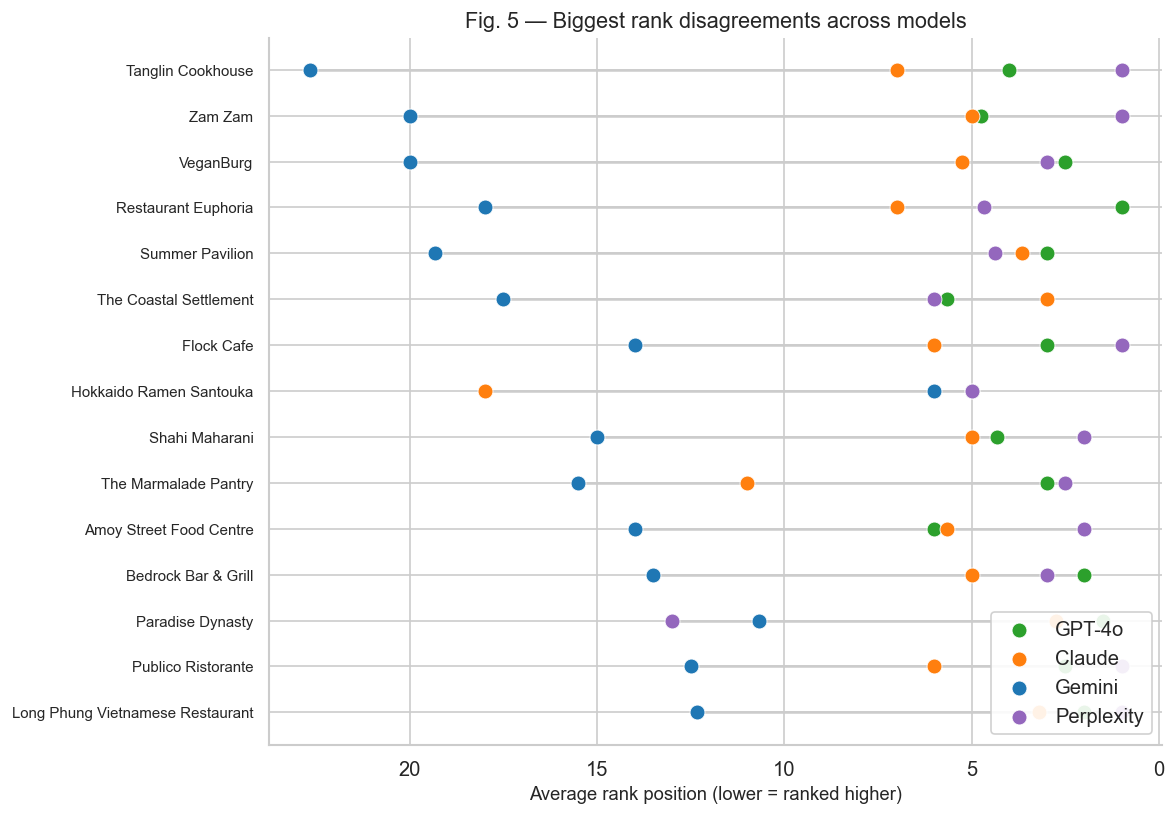

In [10]:
# ── Fig. 5: Rank disagreement — restaurants with biggest rank spread ────────
# Get average rank per restaurant per model (for 4-model consensus set, main sweep)
rank_data = pd.read_sql_query("""
    SELECT
        cr.canonical_name,
        qr.model_name,
        AVG(rm.rank_position) AS avg_rank,
        COUNT(*) AS appearances
    FROM restaurant_mentions rm
    JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
    JOIN query_results qr ON pr.query_result_id = qr.id
    JOIN canonical_restaurants cr ON rm.canonical_id = cr.id
    WHERE qr.is_stability_test = 0
      AND cr.model_count = 4
      AND rm.canonical_id IS NOT NULL
    GROUP BY cr.canonical_name, qr.model_name
""", conn)

# Pivot to get one row per restaurant, columns per model
rank_pivot = rank_data.pivot_table(
    index='canonical_name', columns='model_name', values='avg_rank'
).dropna()  # only keep restaurants ranked by all 4

# Compute rank spread (max - min avg rank across models)
rank_pivot['spread'] = rank_pivot.max(axis=1) - rank_pivot.min(axis=1)
top_disagreement = rank_pivot.nlargest(15, 'spread').drop(columns=['spread'])

# Plot as a dot plot
fig, ax = plt.subplots(figsize=(10, 7))
restaurants = top_disagreement.index.tolist()[::-1]  # reverse for bottom-to-top

for model_name in MODEL_ORDER:
    if model_name in top_disagreement.columns:
        vals = [top_disagreement.loc[r, model_name] for r in restaurants]
        ax.scatter(vals, range(len(restaurants)), color=model_color(model_name),
                   s=80, zorder=3, label=model_short(model_name), edgecolors='white', linewidth=0.5)

# Connect dots with lines to show spread
for i, r in enumerate(restaurants):
    vals = [top_disagreement.loc[r, m] for m in MODEL_ORDER if m in top_disagreement.columns]
    ax.plot([min(vals), max(vals)], [i, i], color='#cccccc', linewidth=1.5, zorder=1)

ax.set_yticks(range(len(restaurants)))
ax.set_yticklabels(restaurants, fontsize=9)
ax.set_xlabel('Average rank position (lower = ranked higher)')
ax.set_title(f'Fig. {next_fig()} — Biggest rank disagreements across models')
ax.legend(loc='lower right', framealpha=0.9)
ax.invert_xaxis()  # lower rank = better, show on right
sns.despine()
plt.tight_layout()
plt.show()

The rank spread reveals each model's personality. Gemini consistently pushes casual/popular spots (hawker centres, chain restaurants) down its lists — a fine-dining bias. GPT-4o and Perplexity often agree on rankings, suggesting overlapping training sources. Claude tends to land in the middle.

---

## Section 3 — Search ON vs OFF

Does web search make AI restaurant recommendations better, different, or just noisier?

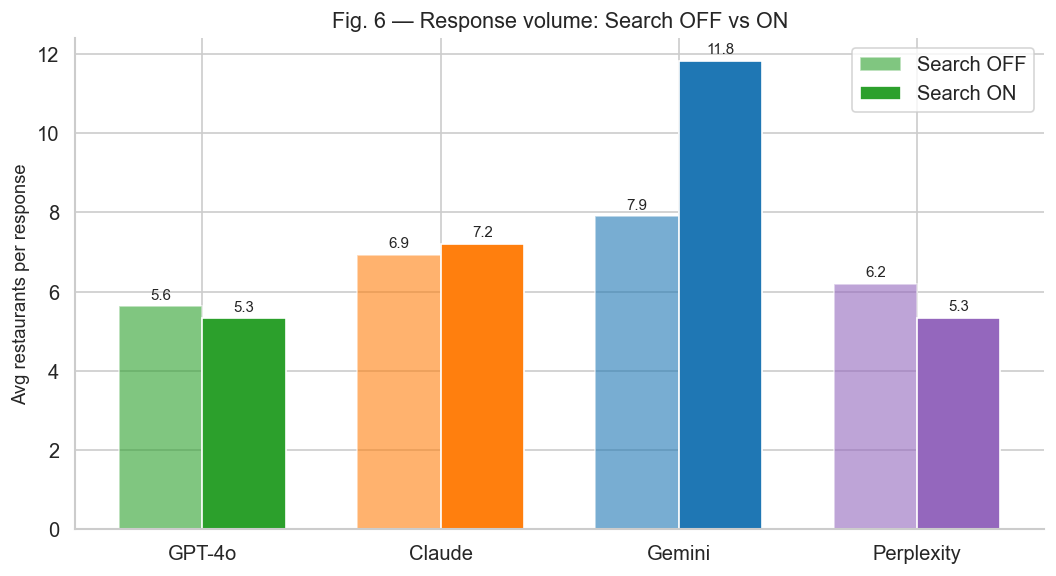

In [11]:
# ── Fig. 6: Avg restaurants per response by model × search mode ──────────────
search_verb = pd.read_sql_query("""
    SELECT qr.model_name, qr.search_enabled, qr.id AS query_id, COUNT(rm.id) AS n_mentions
    FROM query_results qr
    JOIN parsed_responses pr ON pr.query_result_id = qr.id
    LEFT JOIN restaurant_mentions rm ON rm.parsed_response_id = pr.id
    WHERE qr.is_stability_test = 0
    GROUP BY qr.id
""", conn)

sv_stats = search_verb.groupby(['model_name', 'search_enabled'])['n_mentions'].mean().reset_index()
sv_stats['model'] = sv_stats['model_name'].map(model_short)
sv_stats['search'] = sv_stats['search_enabled'].map({0: 'Search OFF', 1: 'Search ON'})

sv_pivot = sv_stats.pivot(index='model', columns='search', values='n_mentions')
sv_pivot = sv_pivot.reindex([model_short(m) for m in MODEL_ORDER])

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(sv_pivot))
width = 0.35

bars_off = ax.bar(x - width/2, sv_pivot['Search OFF'], width, label='Search OFF',
                  color=[model_color(m) for m in MODEL_ORDER], alpha=0.6, edgecolor='white')
bars_on = ax.bar(x + width/2, sv_pivot['Search ON'], width, label='Search ON',
                 color=[model_color(m) for m in MODEL_ORDER], alpha=1.0, edgecolor='white')

for bar in list(bars_off) + list(bars_on):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(sv_pivot.index)
ax.set_ylabel('Avg restaurants per response')
ax.set_title(f'Fig. {next_fig()} — Response volume: Search OFF vs ON')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

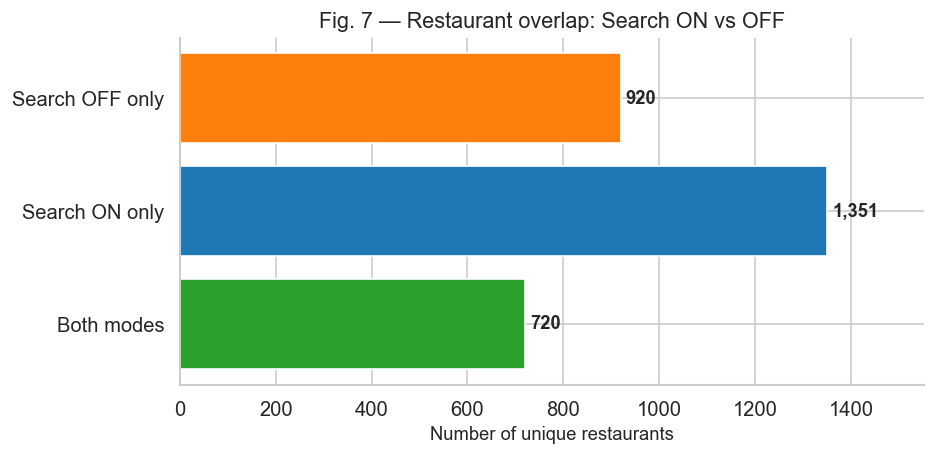

Total unique restaurants (union): 2,991
Overlap: 720 (24.1%) appear in both modes
Search ON surfaces 1,351 restaurants that never appear with search OFF
Search OFF surfaces 920 restaurants that never appear with search ON


In [12]:
# ── Fig. 7: Venn-style breakdown — Search ON only / OFF only / Both ──────────
search_overlap = pd.read_sql_query("""
    WITH on_set AS (
        SELECT DISTINCT rm.canonical_id
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 1 AND rm.canonical_id IS NOT NULL
    ),
    off_set AS (
        SELECT DISTINCT rm.canonical_id
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 0 AND rm.canonical_id IS NOT NULL
    )
    SELECT
        (SELECT COUNT(*) FROM on_set WHERE canonical_id IN (SELECT canonical_id FROM off_set)) AS both,
        (SELECT COUNT(*) FROM on_set WHERE canonical_id NOT IN (SELECT canonical_id FROM off_set)) AS search_on_only,
        (SELECT COUNT(*) FROM off_set WHERE canonical_id NOT IN (SELECT canonical_id FROM on_set)) AS search_off_only
""", conn)

both = search_overlap['both'].values[0]
on_only = search_overlap['search_on_only'].values[0]
off_only = search_overlap['search_off_only'].values[0]

fig, ax = plt.subplots(figsize=(8, 4))
categories = ['Both modes', 'Search ON only', 'Search OFF only']
values = [both, on_only, off_only]
colors_v = ['#2ca02c', '#1f77b4', '#ff7f0e']
bars = ax.barh(categories, values, color=colors_v, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of unique restaurants')
ax.set_title(f'Fig. {next_fig()} — Restaurant overlap: Search ON vs OFF')
ax.set_xlim(0, max(values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

total_union = both + on_only + off_only
print(f"Total unique restaurants (union): {total_union:,}")
print(f"Overlap: {both:,} ({both/total_union*100:.1f}%) appear in both modes")
print(f"Search ON surfaces {on_only:,} restaurants that never appear with search OFF")
print(f"Search OFF surfaces {off_only:,} restaurants that never appear with search ON")

Web search doesn't just refine recommendations — it fundamentally changes them. Only ~24% of restaurants appear in both modes. Search ON brings in over 1,300 restaurants that the models' parametric memory alone would never surface — likely newer openings, recently trending spots, and places with fresh press coverage.

In [13]:
# ── Table 4: Search-only restaurants (5+ mentions with search ON, 0 with OFF)
search_only = pd.read_sql_query("""
    WITH on_counts AS (
        SELECT rm.canonical_id, COUNT(*) AS on_mentions
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 1 AND rm.canonical_id IS NOT NULL
        GROUP BY rm.canonical_id
    ),
    off_ids AS (
        SELECT DISTINCT rm.canonical_id
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 0 AND rm.canonical_id IS NOT NULL
    )
    SELECT cr.canonical_name AS restaurant, oc.on_mentions AS mentions_search_on
    FROM on_counts oc
    JOIN canonical_restaurants cr ON oc.canonical_id = cr.id
    WHERE oc.canonical_id NOT IN (SELECT canonical_id FROM off_ids)
      AND oc.on_mentions >= 5
    ORDER BY oc.on_mentions DESC
    LIMIT 15
""", conn)

print("Table 4 — Search-only restaurants (≥5 mentions with search ON, zero with search OFF)")
print("These are likely newer openings or places with recent press not in parametric memory.")
print()
search_only

Table 4 — Search-only restaurants (≥5 mentions with search ON, zero with search OFF)
These are likely newer openings or places with recent press not in parametric memory.



,restaurant,mentions_search_on
0,Rumah Makan Minang,7
1,Colbar,6
2,Lau Pa Sat Satay Street,6
3,Vineyard at HortPark,6
4,AMOR,5
5,Casa Vostra,5
6,HighHouse,5
7,Tamba,5
8,The Refinery,5


In [14]:
# ── Table 5: Parametric-only restaurants (5+ mentions OFF, 0 with ON) ────────
param_only = pd.read_sql_query("""
    WITH off_counts AS (
        SELECT rm.canonical_id, COUNT(*) AS off_mentions
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 0 AND rm.canonical_id IS NOT NULL
        GROUP BY rm.canonical_id
    ),
    on_ids AS (
        SELECT DISTINCT rm.canonical_id
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0 AND qr.search_enabled = 1 AND rm.canonical_id IS NOT NULL
    )
    SELECT cr.canonical_name AS restaurant, oc.off_mentions AS mentions_search_off
    FROM off_counts oc
    JOIN canonical_restaurants cr ON oc.canonical_id = cr.id
    WHERE oc.canonical_id NOT IN (SELECT canonical_id FROM on_ids)
      AND oc.off_mentions >= 5
    ORDER BY oc.off_mentions DESC
    LIMIT 15
""", conn)

if len(param_only) > 0:
    print("Table 5 — Parametric-only restaurants (≥5 mentions with search OFF, zero with search ON)")
    print("These restaurants exist in parametric memory but get displaced when search is enabled.")
    print()
    display(param_only)
else:
    print("Table 5 — No restaurants with ≥5 parametric-only mentions found.")
    print("Search ON mostly adds restaurants rather than displacing parametric ones.")

Table 5 — Parametric-only restaurants (≥5 mentions with search OFF, zero with search ON)
These restaurants exist in parametric memory but get displaced when search is enabled.



,restaurant,mentions_search_off
0,Chomp Chomp Food Centre,9
1,Preludio,9
2,Kinki Restaurant + Bar,6
3,Jag,5
4,Keisuke Tonkotsu King,5
5,Old Chang Kee,5


The search-only restaurants are the clearest signal of **training data staleness** — these are places the models don't "know" from pre-training but can find via live web search. This is the strongest argument for search-augmented recommendations: they surface a fundamentally different (and likely more current) set of restaurants.

---

## Section 4 — The Zombie Restaurant Problem

The headline finding: **AI models confidently recommend restaurants that no longer exist.** We cross-reference our mentions against Google Places ground truth to quantify how bad this is.

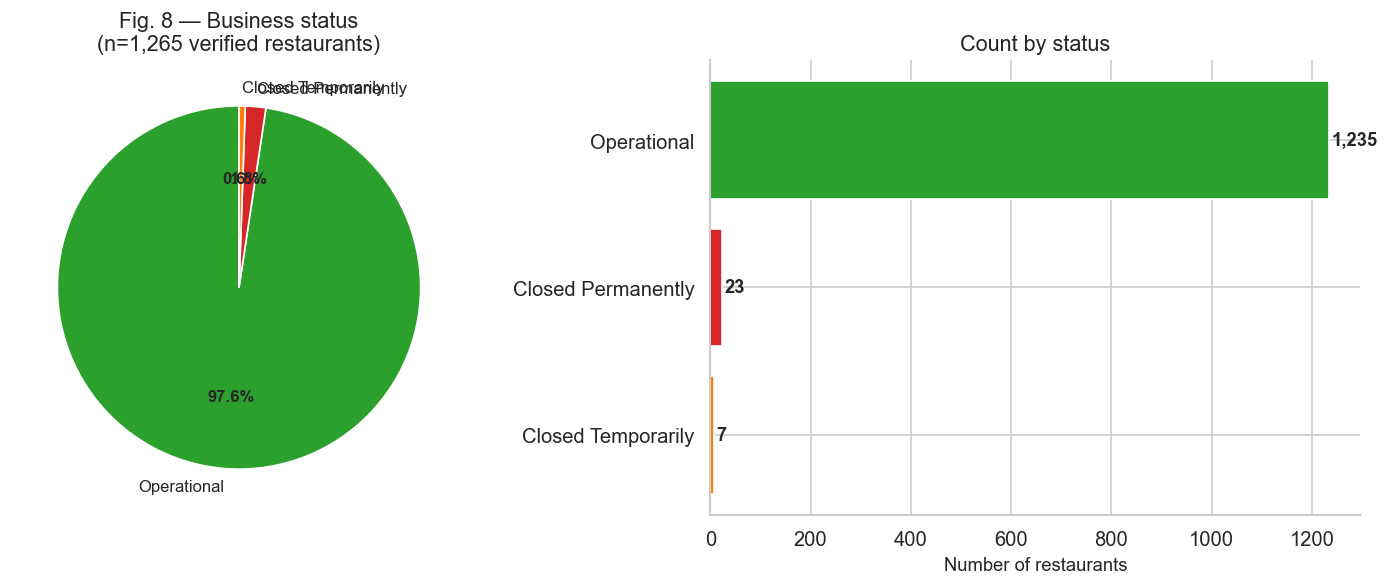


30 of 1,265 verified restaurants are closed (2.4%)
  → 23 permanently closed
  → 7 temporarily closed


In [15]:
# ── Fig. 8: Business status of AI-recommended restaurants (verified set) ─────
status_data = pd.read_sql_query("""
    SELECT gp.business_status, COUNT(*) AS count
    FROM google_places gp
    JOIN canonical_restaurants cr ON gp.canonical_id = cr.id
    WHERE gp.human_verified = 1 AND cr.model_count > 0
    GROUP BY gp.business_status
    ORDER BY count DESC
""", conn)

# Handle potential missing statuses gracefully
if len(status_data) == 0:
    print("No verified Google Places data found — skipping Section 4.")
else:
    total_verified = status_data['count'].sum()
    
    # Colors: green for open, red for permanently closed, amber for temporarily closed
    status_colors = {
        'OPERATIONAL': '#2ca02c',
        'CLOSED_PERMANENTLY': '#d62728',
        'CLOSED_TEMPORARILY': '#ff7f0e'
    }
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                    gridspec_kw={'width_ratios': [1, 1.3]})
    
    # Pie chart
    pie_colors = [status_colors.get(s, '#999') for s in status_data['business_status']]
    pie_labels = [s.replace('_', ' ').title() for s in status_data['business_status']]
    wedges, texts, autotexts = ax1.pie(
        status_data['count'], labels=pie_labels, colors=pie_colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10}
    )
    for t in autotexts:
        t.set_fontweight('bold')
    ax1.set_title(f'Fig. {next_fig()} — Business status\n(n={total_verified:,} verified restaurants)')
    
    # Bar chart with counts
    bars = ax2.barh(pie_labels[::-1], status_data['count'].values[::-1],
                     color=pie_colors[::-1], edgecolor='white')
    for bar, val in zip(bars, status_data['count'].values[::-1]):
        ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Number of restaurants')
    ax2.set_title('Count by status')
    sns.despine(ax=ax2)
    
    plt.tight_layout()
    plt.show()
    
    closed_perm = status_data.loc[status_data['business_status'] == 'CLOSED_PERMANENTLY', 'count']
    closed_temp = status_data.loc[status_data['business_status'] == 'CLOSED_TEMPORARILY', 'count']
    closed_perm_n = closed_perm.values[0] if len(closed_perm) > 0 else 0
    closed_temp_n = closed_temp.values[0] if len(closed_temp) > 0 else 0
    closed_total = closed_perm_n + closed_temp_n
    print(f"\n{closed_total} of {total_verified:,} verified restaurants are closed ({closed_total/total_verified*100:.1f}%)")
    print(f"  → {closed_perm_n} permanently closed")
    print(f"  → {closed_temp_n} temporarily closed")

In [16]:
# ── Table 6: Top closed restaurants by mention count ─────────────────────────
closed_top = pd.read_sql_query("""
    SELECT
        cr.canonical_name AS restaurant,
        cr.total_mentions AS mentions,
        cr.model_count AS models,
        gp.business_status AS status,
        gp.rating,
        gp.user_ratings_total AS reviews
    FROM canonical_restaurants cr
    JOIN google_places gp ON gp.canonical_id = cr.id
    WHERE gp.human_verified = 1
      AND gp.business_status LIKE 'CLOSED%'
      AND cr.model_count > 0
    ORDER BY cr.total_mentions DESC
""", conn)

closed_top['status'] = closed_top['status'].str.replace('_', ' ').str.title()
closed_top.index = range(1, len(closed_top) + 1)
closed_top.index.name = '#'

print(f"Table 6 — Closed restaurants still recommended by AI (n={len(closed_top)})")
print(f"These are \"zombie restaurants\" — confidently recommended but no longer operating.")
print()
closed_top.head(15)

Table 6 — Closed restaurants still recommended by AI (n=30)


These are "zombie restaurants" — confidently recommended but no longer operating.



,restaurant,mentions,models,status,rating,reviews
#,,,,,,
1,Open Farm Community,44,4,Closed Permanently,4.2,2211.0
2,Corner House,33,4,Closed Permanently,4.6,996.0
3,Shinji by Kanesaka,32,4,Closed Permanently,4.6,504.0
4,Cicheti,27,3,Closed Permanently,4.1,643.0
5,Lolla,23,4,Closed Permanently,4.5,566.0
6,Afterglow,18,4,Closed Permanently,4.1,544.0
7,Esora,16,4,Closed Permanently,4.4,253.0
8,Hashida Sushi,16,4,Closed Permanently,4.8,81.0
9,OverEasy,13,3,Closed Temporarily,4.3,3094.0


Open Farm Community — 44 mentions from all 4 models — hasn't been open for some time. Corner House (Michelin-starred, 33 mentions) is permanently closed. These aren't edge cases; they're among the most-recommended restaurants in the dataset. A user following any of these AI suggestions would arrive at a shuttered door.

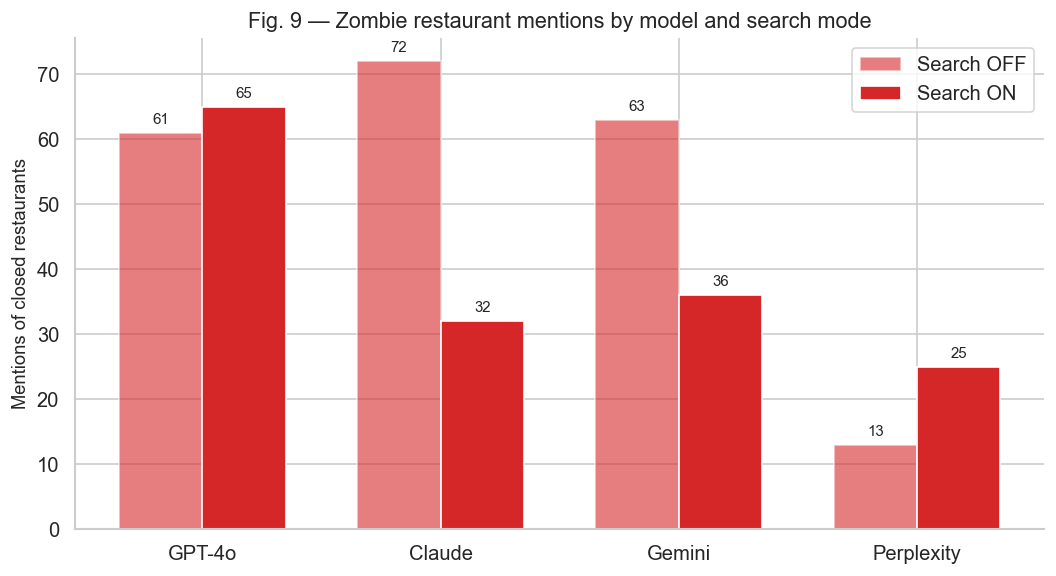


Search OFF: 209 closed-restaurant mentions
Search ON:  158 closed-restaurant mentions
Search reduces zombie mentions by 24%


In [17]:
# ── Fig. 9: Closed restaurant mentions by model ──────────────────────────────
# Get closed canonical_ids
closed_ids = pd.read_sql_query("""
    SELECT cr.id AS canonical_id
    FROM canonical_restaurants cr
    JOIN google_places gp ON gp.canonical_id = cr.id
    WHERE gp.human_verified = 1 AND gp.business_status LIKE 'CLOSED%' AND cr.model_count > 0
""", conn)['canonical_id'].tolist()

if closed_ids:
    placeholders = ','.join(['?'] * len(closed_ids))
    closed_by_model = pd.read_sql_query(f"""
        SELECT
            qr.model_name,
            qr.search_enabled,
            COUNT(rm.id) AS closed_mentions
        FROM restaurant_mentions rm
        JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
        JOIN query_results qr ON pr.query_result_id = qr.id
        WHERE qr.is_stability_test = 0
          AND rm.canonical_id IN ({placeholders})
        GROUP BY qr.model_name, qr.search_enabled
    """, conn, params=closed_ids)
    
    closed_by_model['model'] = closed_by_model['model_name'].map(model_short)
    closed_by_model['search'] = closed_by_model['search_enabled'].map({0: 'Search OFF', 1: 'Search ON'})
    
    cbm_pivot = closed_by_model.pivot(index='model', columns='search', values='closed_mentions').fillna(0)
    cbm_pivot = cbm_pivot.reindex([model_short(m) for m in MODEL_ORDER])
    
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(cbm_pivot))
    width = 0.35
    
    bars_off = ax.bar(x - width/2, cbm_pivot['Search OFF'], width,
                      label='Search OFF', color='#d62728', alpha=0.6)
    bars_on = ax.bar(x + width/2, cbm_pivot['Search ON'], width,
                     label='Search ON', color='#d62728', alpha=1.0)
    
    for bar in list(bars_off) + list(bars_on):
        if bar.get_height() > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(cbm_pivot.index)
    ax.set_ylabel('Mentions of closed restaurants')
    ax.set_title(f'Fig. {next_fig()} — Zombie restaurant mentions by model and search mode')
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    total_off = cbm_pivot['Search OFF'].sum()
    total_on = cbm_pivot['Search ON'].sum()
    if total_off > 0:
        print(f"\nSearch OFF: {int(total_off)} closed-restaurant mentions")
        print(f"Search ON:  {int(total_on)} closed-restaurant mentions")
        pct_reduction = (total_off - total_on) / total_off * 100
        print(f"Search reduces zombie mentions by {pct_reduction:.0f}%" if pct_reduction > 0
              else f"Search does not reduce zombie mentions")

Web search helps — but doesn't eliminate — the zombie restaurant problem. Even with live web access, models still recommend some closed restaurants, suggesting they blend parametric memory (stale) with search results (current), and the parametric signal sometimes wins.

---

## Section 5 — Recommendation Stability

If you ask the same question twice, do you get the same restaurants? We re-ran 15 prompts 5 times each to find out. **This section includes the 675 stability-only canonical entries.**

In [18]:
# ── Compute pairwise Jaccard similarities from stability test data ──────────
# For each (prompt, model, search_enabled) cell, compute pairwise Jaccard
# between all run pairs

stability_mentions = pd.read_sql_query("""
    SELECT
        qr.prompt_id,
        qr.model_name,
        qr.search_enabled,
        qr.run_number,
        rm.canonical_id
    FROM query_results qr
    JOIN parsed_responses pr ON pr.query_result_id = qr.id
    JOIN restaurant_mentions rm ON rm.parsed_response_id = pr.id
    WHERE qr.is_stability_test = 1 AND rm.canonical_id IS NOT NULL
""", conn)

# Get prompts with their specificity
stab_prompts = pd.read_sql_query("""
    SELECT DISTINCT dp.id AS prompt_id, dp.specificity
    FROM discovery_prompts dp
    JOIN query_results qr ON qr.prompt_id = dp.id
    WHERE qr.is_stability_test = 1
""", conn)

stability_mentions = stability_mentions.merge(stab_prompts, on='prompt_id', how='left')

# Compute Jaccard for each cell
jaccard_records = []
cells = stability_mentions.groupby(['prompt_id', 'model_name', 'search_enabled'])

for (pid, model, search), group in cells:
    runs = group.groupby('run_number')['canonical_id'].apply(set).to_dict()
    run_nums = sorted(runs.keys())
    specificity = group['specificity'].iloc[0]
    
    for i, j in combinations(run_nums, 2):
        s1, s2 = runs[i], runs[j]
        union = len(s1 | s2)
        intersection = len(s1 & s2)
        jac = intersection / union if union > 0 else 0
        jaccard_records.append({
            'prompt_id': pid,
            'model_name': model,
            'search_enabled': search,
            'specificity': specificity,
            'jaccard': jac
        })

jac_df = pd.DataFrame(jaccard_records)
print(f"Computed {len(jac_df):,} pairwise Jaccard values across {len(cells)} cells")
print(f"Overall mean Jaccard: {jac_df['jaccard'].mean():.3f}")

Computed 1,060 pairwise Jaccard values across 118 cells
Overall mean Jaccard: 0.261


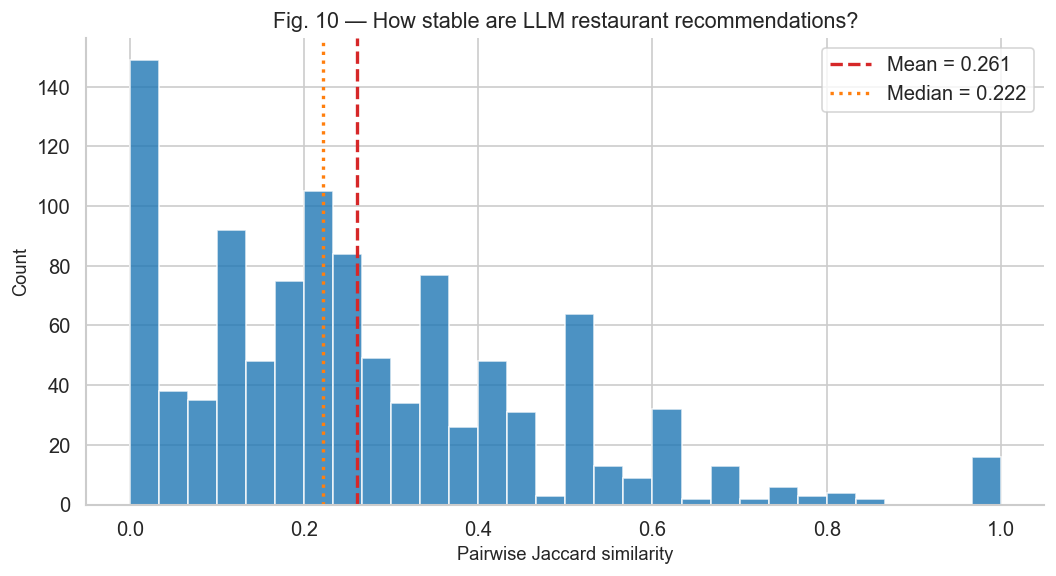

Only ~10% of run pairs share more than half their restaurants.


In [19]:
# ── Fig. 10: Distribution of Jaccard similarities ────────────────────────────
fnum = next_fig()
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(jac_df['jaccard'], bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
ax.axvline(jac_df['jaccard'].mean(), color='#d62728', linestyle='--', linewidth=2,
           label=f'Mean = {jac_df["jaccard"].mean():.3f}')
ax.axvline(jac_df['jaccard'].median(), color='#ff7f0e', linestyle=':', linewidth=2,
           label=f'Median = {jac_df["jaccard"].median():.3f}')
ax.set_xlabel('Pairwise Jaccard similarity')
ax.set_ylabel('Count')
ax.set_title(f'Fig. {fnum} — How stable are LLM restaurant recommendations?')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print(f"Only ~{(jac_df['jaccard'] > 0.5).mean()*100:.0f}% of run pairs share more than half their restaurants.")

The Jaccard distribution is skewed low — most run pairs have less than 30% overlap. Ask the same model the same question twice, and roughly 3 out of 4 restaurants in each response will be different. LLM recommendations are far less stable than users probably assume.

/var/folders/z_/y8g51kys2hxg5vw46rfbg7vh0000gn/T/ipykernel_46845/1099900212.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(model_data, labels=model_labels, patch_artist=True, widths=0.6,


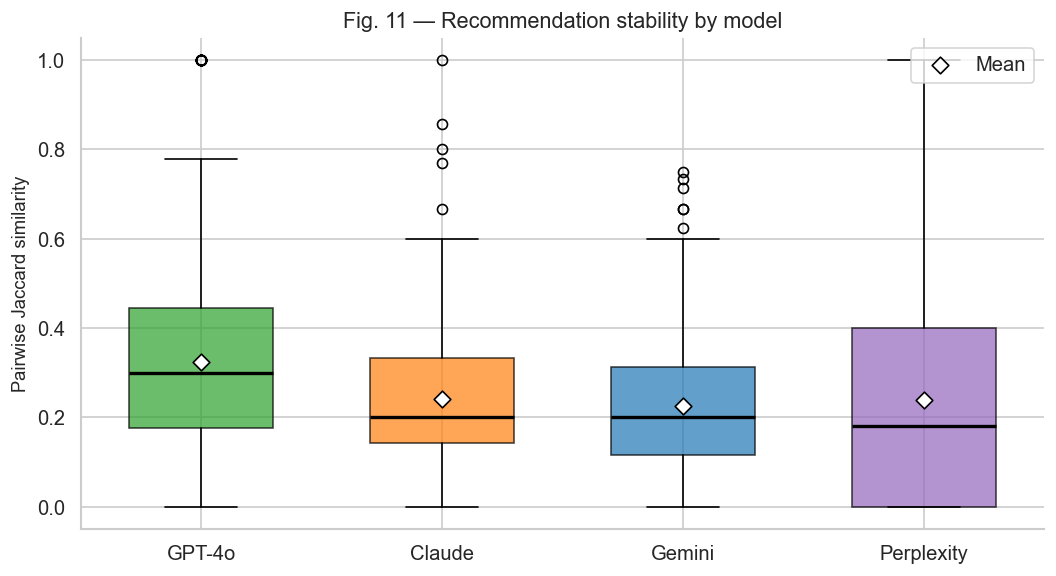

Per-model mean Jaccard:
  GPT-4o       0.325
  Claude       0.242
  Gemini       0.227
  Perplexity   0.240


In [20]:
# ── Fig. 11: Per-model stability (Jaccard box plots) ─────────────────────────
fnum = next_fig()
jac_df['model'] = jac_df['model_name'].map(model_short)

fig, ax = plt.subplots(figsize=(9, 5))
model_labels = [model_short(m) for m in MODEL_ORDER]
model_data = [jac_df.loc[jac_df['model_name'] == m, 'jaccard'].values for m in MODEL_ORDER]

bp = ax.boxplot(model_data, labels=model_labels, patch_artist=True, widths=0.6,
                medianprops={'color': 'black', 'linewidth': 2})

for patch, m in zip(bp['boxes'], MODEL_ORDER):
    patch.set_facecolor(model_color(m))
    patch.set_alpha(0.7)

# Add mean markers
means = [jac_df.loc[jac_df['model_name'] == m, 'jaccard'].mean() for m in MODEL_ORDER]
ax.scatter(range(1, 5), means, marker='D', color='white', edgecolors='black', s=50, zorder=5, label='Mean')

ax.set_ylabel('Pairwise Jaccard similarity')
ax.set_title(f'Fig. {fnum} — Recommendation stability by model')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

print("Per-model mean Jaccard:")
for m, mean in zip(MODEL_ORDER, means):
    print(f"  {model_short(m):<12} {mean:.3f}")

GPT-4o is the most stable — its shorter lists (~5.5 per response) mean each pick is more "committed." Gemini's 10.9 per response gives it more room for stochastic variation. Perplexity and Claude fall in between.

/var/folders/z_/y8g51kys2hxg5vw46rfbg7vh0000gn/T/ipykernel_46845/673541332.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(spec_data, labels=[s.title() for s in spec_order], patch_artist=True, widths=0.6,


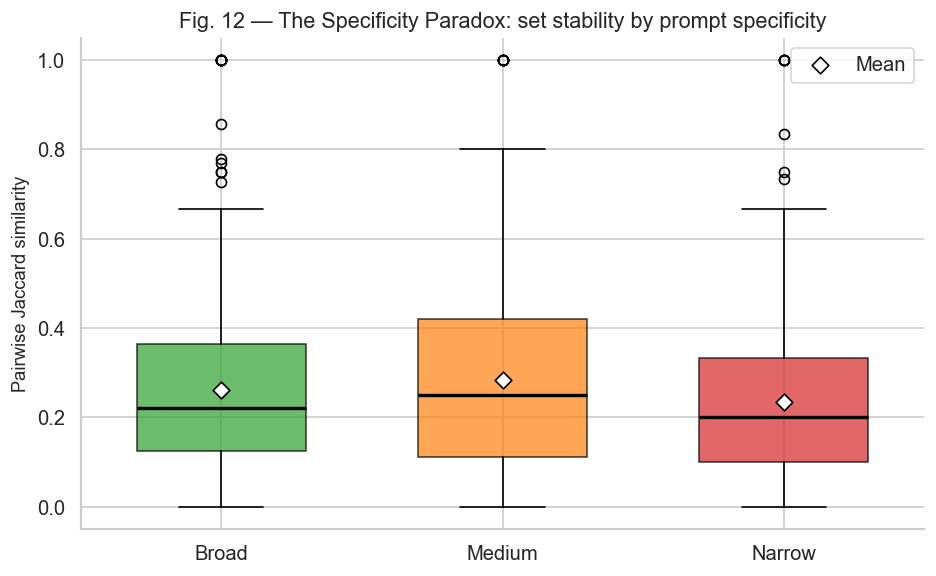

Mean Jaccard by specificity:
  broad    0.261
  medium   0.284
  narrow   0.235

Narrow prompts have WORST set overlap but BEST rank correlation (see OBSERVATIONS.md §10).
Few obvious candidates → different draws each run, but consistent ranking when they overlap.


In [21]:
# ── Fig. 12: The Specificity Paradox — Jaccard vs specificity ─────────────────
fnum = next_fig()
spec_order = ['broad', 'medium', 'narrow']

fig, ax = plt.subplots(figsize=(8, 5))
spec_data = [jac_df.loc[jac_df['specificity'] == s, 'jaccard'].values for s in spec_order]
spec_means = [np.mean(d) for d in spec_data]

bp = ax.boxplot(spec_data, labels=[s.title() for s in spec_order], patch_artist=True, widths=0.6,
                medianprops={'color': 'black', 'linewidth': 2})

spec_colors = ['#2ca02c', '#ff7f0e', '#d62728']
for patch, c in zip(bp['boxes'], spec_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.scatter(range(1, 4), spec_means, marker='D', color='white', edgecolors='black', s=50, zorder=5, label='Mean')

ax.set_ylabel('Pairwise Jaccard similarity')
ax.set_title(f'Fig. {fnum} — The Specificity Paradox: set stability by prompt specificity')
ax.legend(loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

print("Mean Jaccard by specificity:")
for s, m in zip(spec_order, spec_means):
    print(f"  {s:<8} {m:.3f}")
print("\nNarrow prompts have WORST set overlap but BEST rank correlation (see OBSERVATIONS.md §10).")
print("Few obvious candidates → different draws each run, but consistent ranking when they overlap.")

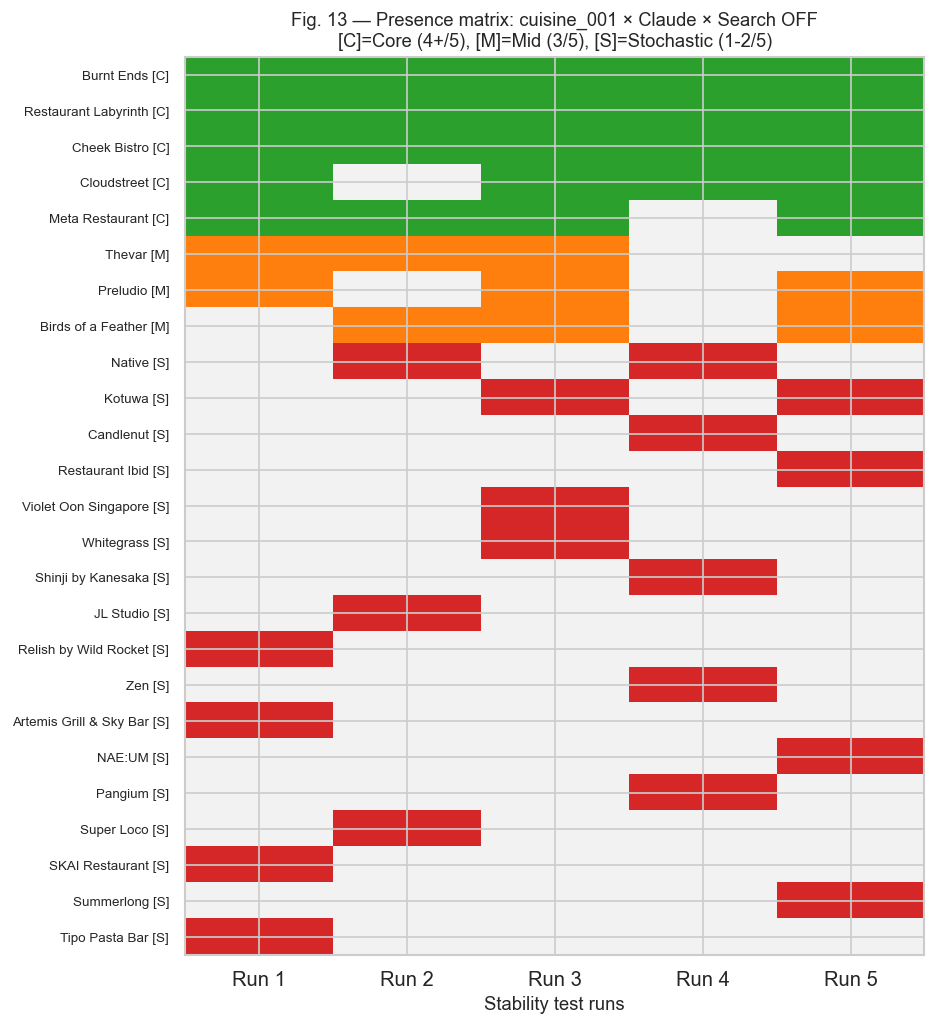


5 core restaurants, 3 mid, 17 stochastic
The 5 core restaurants are Claude's genuine anchors for this prompt.
The 17 stochastic restaurants are drawn from a larger implicit distribution.


In [22]:
# ── Fig. 13: Core vs Stochastic — presence/absence matrix for one prompt ────
# Pick cuisine_001 × Claude × Search OFF as the example
example_data = pd.read_sql_query("""
    SELECT
        qr.run_number,
        cr.canonical_name,
        rm.rank_position
    FROM query_results qr
    JOIN parsed_responses pr ON pr.query_result_id = qr.id
    JOIN restaurant_mentions rm ON rm.parsed_response_id = pr.id
    JOIN canonical_restaurants cr ON rm.canonical_id = cr.id
    WHERE qr.is_stability_test = 1
      AND qr.prompt_id = 'cuisine_001'
      AND qr.model_name = 'anthropic/claude-sonnet-4-20250514'
      AND qr.search_enabled = 0
    ORDER BY qr.run_number, rm.rank_position
""", conn)

if len(example_data) > 0:
    fnum = next_fig()
    # Create presence/absence matrix
    runs = sorted(example_data['run_number'].unique())
    all_restaurants = example_data['canonical_name'].unique()
    
    # Count appearances to classify
    appearance_count = example_data.groupby('canonical_name')['run_number'].nunique()
    
    # Sort: core (most appearances) first, then by first appearance rank
    first_rank = example_data.groupby('canonical_name')['rank_position'].min()
    sort_df = pd.DataFrame({'appearances': appearance_count, 'first_rank': first_rank})
    sort_df = sort_df.sort_values(['appearances', 'first_rank'], ascending=[False, True])
    sorted_restaurants = sort_df.index.tolist()
    
    # Build matrix
    matrix = np.zeros((len(sorted_restaurants), len(runs)))
    for _, row in example_data.iterrows():
        ri = sorted_restaurants.index(row['canonical_name'])
        ci = runs.index(row['run_number'])
        matrix[ri, ci] = 1
    
    # Classify restaurants
    classifications = []
    for r in sorted_restaurants:
        n = appearance_count[r]
        n_runs = len(runs)
        if n >= n_runs * 0.8:  # 4+/5
            classifications.append('Core')
        elif n >= n_runs * 0.6:  # 3/5
            classifications.append('Mid')
        else:
            classifications.append('Stochastic')
    
    fig, ax = plt.subplots(figsize=(8, max(6, len(sorted_restaurants) * 0.35)))
    
    # Color by classification
    class_colors = {'Core': '#2ca02c', 'Mid': '#ff7f0e', 'Stochastic': '#d62728'}
    colored_matrix = np.zeros((*matrix.shape, 3))
    for i, cls in enumerate(classifications):
        color_hex = class_colors[cls]
        r = int(color_hex[1:3], 16) / 255
        g = int(color_hex[3:5], 16) / 255
        b = int(color_hex[5:7], 16) / 255
        for j in range(matrix.shape[1]):
            if matrix[i, j] > 0:
                colored_matrix[i, j] = [r, g, b]
            else:
                colored_matrix[i, j] = [0.95, 0.95, 0.95]
    
    ax.imshow(colored_matrix, aspect='auto', interpolation='nearest')
    
    ax.set_xticks(range(len(runs)))
    ax.set_xticklabels([f'Run {r}' for r in runs])
    ax.set_yticks(range(len(sorted_restaurants)))
    y_labels = [f'{r} [{c[0]}]' for r, c in zip(sorted_restaurants, classifications)]
    ax.set_yticklabels(y_labels, fontsize=8)
    
    ax.set_title(f'Fig. {fnum} — Presence matrix: cuisine_001 × Claude × Search OFF\n'
                 f'[C]=Core (4+/5), [M]=Mid (3/5), [S]=Stochastic (1-2/5)', fontsize=11)
    ax.set_xlabel('Stability test runs')
    
    plt.tight_layout()
    plt.show()
    
    core_n = classifications.count('Core')
    stoch_n = classifications.count('Stochastic')
    print(f"\n{core_n} core restaurants, {classifications.count('Mid')} mid, {stoch_n} stochastic")
    print(f"The {core_n} core restaurants are Claude's genuine anchors for this prompt.")
    print(f"The {stoch_n} stochastic restaurants are drawn from a larger implicit distribution.")
else:
    print("No stability data found for cuisine_001 × Claude × Search OFF — skipping example.")

This matrix reveals the dual nature of LLM recommendations: a small set of "anchor" restaurants that reliably appear (the core), surrounded by a much larger pool of stochastic candidates that rotate in and out. The model *knows* all of them, but can't consistently decide which to include.

---

## Section 6 — What Predicts AI Recommendations?

Using our ~1,267 human-verified Google Places matches, we can ask: what real-world signals predict whether an AI model will recommend a restaurant?

In [23]:
# ── Load ground truth data ───────────────────────────────────────────────────
ground_truth = pd.read_sql_query("""
    SELECT
        cr.id AS canonical_id,
        cr.canonical_name,
        cr.total_mentions,
        cr.model_count,
        gp.rating,
        gp.user_ratings_total AS reviews,
        gp.price_level,
        gp.business_status
    FROM canonical_restaurants cr
    JOIN google_places gp ON gp.canonical_id = cr.id
    WHERE gp.human_verified = 1 AND cr.model_count > 0
      AND gp.business_status = 'OPERATIONAL'
""", conn)

print(f"Ground truth dataset: {len(ground_truth):,} operational, verified restaurants")
print(f"  with rating:       {ground_truth['rating'].notna().sum():,}")
print(f"  with reviews:      {ground_truth['reviews'].notna().sum():,}")
print(f"  with price_level:  {ground_truth['price_level'].notna().sum():,}")

Ground truth dataset: 1,235 operational, verified restaurants
  with rating:       1,228
  with reviews:      1,228
  with price_level:  583


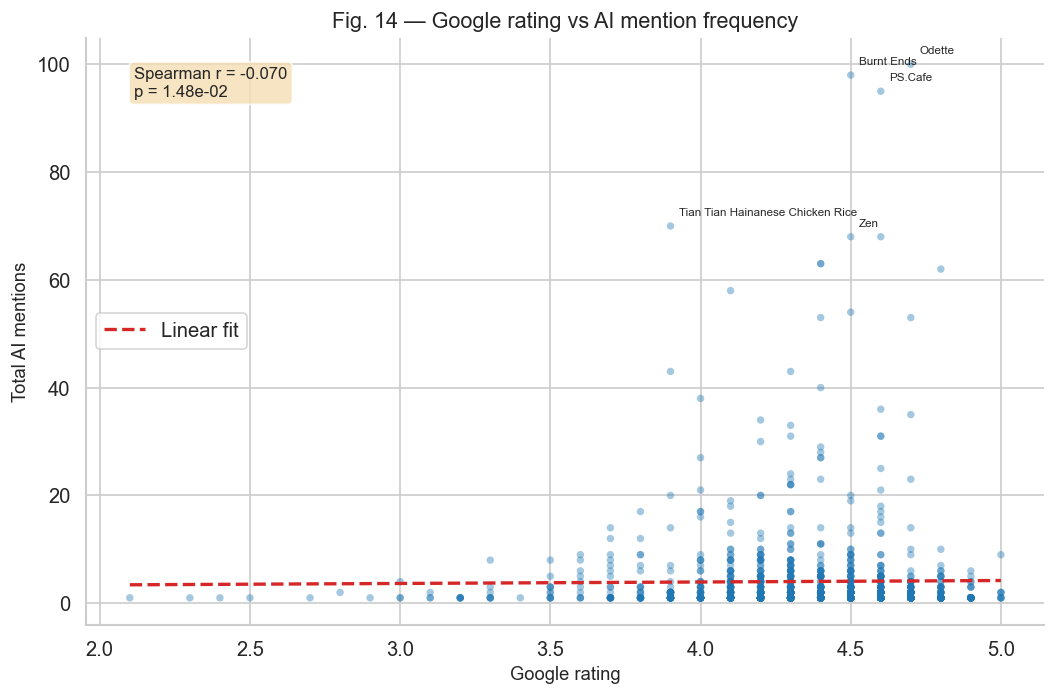

In [24]:
# ── Fig. 14: Google rating vs AI mention count ───────────────────────────────
fnum = next_fig()
gt = ground_truth.dropna(subset=['rating']).copy()

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(gt['rating'], gt['total_mentions'], alpha=0.4, s=20, c='#1f77b4', edgecolors='none')

# Trend line
z = np.polyfit(gt['rating'], gt['total_mentions'], 1)
p = np.poly1d(z)
x_line = np.linspace(gt['rating'].min(), gt['rating'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#d62728', linewidth=2, label=f'Linear fit')

# Correlation
r, pval = stats.spearmanr(gt['rating'], gt['total_mentions'])
ax.text(0.05, 0.95, f'Spearman r = {r:.3f}\np = {pval:.2e}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Label top outliers
top_mentions = gt.nlargest(5, 'total_mentions')
for _, row in top_mentions.iterrows():
    ax.annotate(row['canonical_name'], (row['rating'], row['total_mentions']),
                fontsize=7, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Google rating')
ax.set_ylabel('Total AI mentions')
ax.set_title(f'Fig. {fnum} — Google rating vs AI mention frequency')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

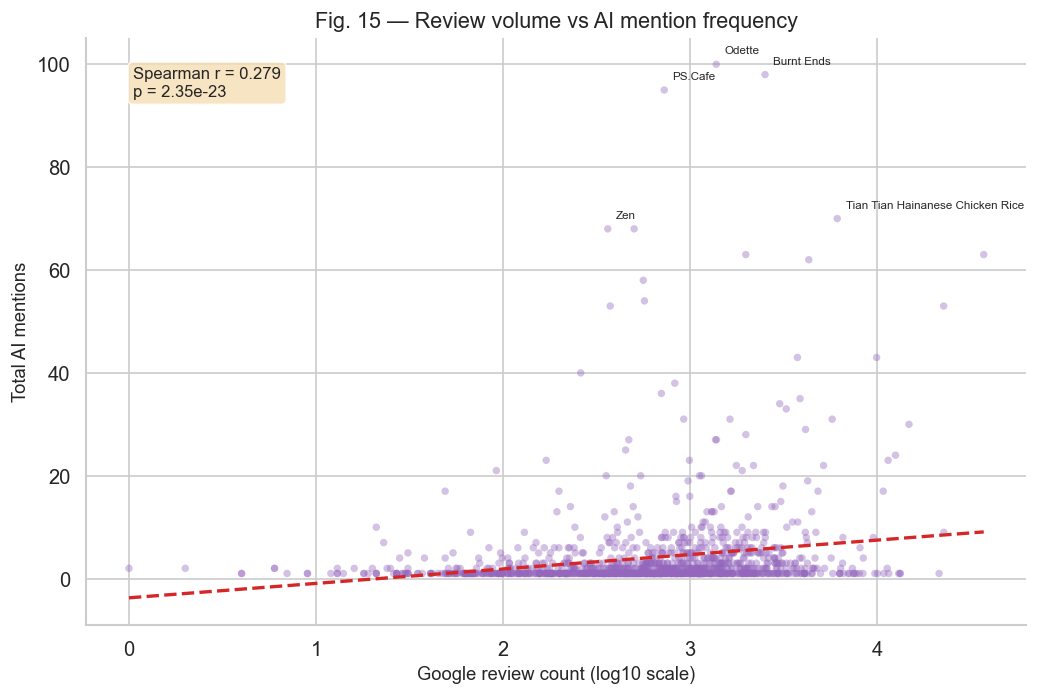

In [25]:
# ── Fig. 15: Google review count (log) vs AI mentions ────────────────────────
fnum = next_fig()
gt_rev = ground_truth.dropna(subset=['reviews']).copy()
gt_rev = gt_rev[gt_rev['reviews'] > 0]
gt_rev['log_reviews'] = np.log10(gt_rev['reviews'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(gt_rev['log_reviews'], gt_rev['total_mentions'], alpha=0.4, s=20, c='#9467bd', edgecolors='none')

# Trend line
z = np.polyfit(gt_rev['log_reviews'], gt_rev['total_mentions'], 1)
p = np.poly1d(z)
x_line = np.linspace(gt_rev['log_reviews'].min(), gt_rev['log_reviews'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#d62728', linewidth=2)

r, pval = stats.spearmanr(gt_rev['log_reviews'], gt_rev['total_mentions'])
ax.text(0.05, 0.95, f'Spearman r = {r:.3f}\np = {pval:.2e}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

top_mentions = gt_rev.nlargest(5, 'total_mentions')
for _, row in top_mentions.iterrows():
    ax.annotate(row['canonical_name'], (row['log_reviews'], row['total_mentions']),
                fontsize=7, ha='left', va='bottom',
                xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('Google review count (log10 scale)')
ax.set_ylabel('Total AI mentions')
ax.set_title(f'Fig. {fnum} — Review volume vs AI mention frequency')
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/z_/y8g51kys2hxg5vw46rfbg7vh0000gn/T/ipykernel_46845/646894870.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(price_data, labels=[price_labels.get(p, str(p)) for p in price_levels],


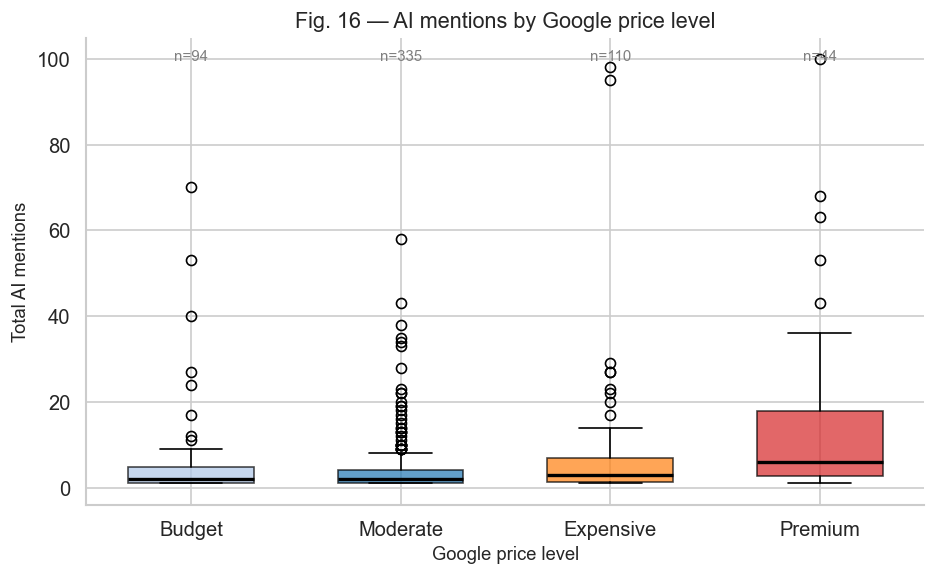

In [26]:
# ── Fig. 16: AI mentions by Google price level ───────────────────────────────
gt_price = ground_truth.dropna(subset=['price_level']).copy()
gt_price['price_level'] = gt_price['price_level'].astype(int)

if len(gt_price) > 0 and gt_price['price_level'].nunique() > 1:
    fnum = next_fig()
    fig, ax = plt.subplots(figsize=(8, 5))
    
    price_labels = {0: 'Free', 1: 'Budget', 2: 'Moderate', 3: 'Expensive', 4: 'Premium'}
    price_levels = sorted(gt_price['price_level'].unique())
    price_data = [gt_price.loc[gt_price['price_level'] == p, 'total_mentions'].values for p in price_levels]
    
    bp = ax.boxplot(price_data, labels=[price_labels.get(p, str(p)) for p in price_levels],
                    patch_artist=True, widths=0.6,
                    medianprops={'color': 'black', 'linewidth': 2})
    
    price_colors = ['#aec7e8', '#1f77b4', '#ff7f0e', '#d62728']
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(price_colors[min(i, len(price_colors)-1)])
        patch.set_alpha(0.7)
    
    # Annotate counts
    for i, p in enumerate(price_levels):
        n = len(gt_price[gt_price['price_level'] == p])
        ax.text(i + 1, ax.get_ylim()[1] * 0.95, f'n={n}', ha='center', fontsize=9, color='gray')
    
    ax.set_xlabel('Google price level')
    ax.set_ylabel('Total AI mentions')
    ax.set_title(f'Fig. {fnum} — AI mentions by Google price level')
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient price level data for box plot — skipping.")

In [27]:
# ── Table 7: Correlation summary ─────────────────────────────────────────────
corr_results = []

for col, label in [('rating', 'Google rating'), ('reviews', 'Review count (log10)'), ('price_level', 'Price level')]:
    subset = ground_truth.dropna(subset=[col]).copy()
    if col == 'reviews':
        subset = subset[subset['reviews'] > 0]
        vals = np.log10(subset['reviews'])
    else:
        vals = subset[col]
    
    if len(subset) > 10:
        r, pval = stats.spearmanr(vals, subset['total_mentions'])
        corr_results.append({'Signal': label, 'Spearman r': f'{r:.3f}',
                             'p-value': f'{pval:.2e}', 'n': len(subset)})

corr_df = pd.DataFrame(corr_results)
print("Table 7 — Which Google signal best predicts AI mention frequency?")
corr_df

Table 7 — Which Google signal best predicts AI mention frequency?


,Signal,Spearman r,p-value,n
0,Google rating,-0.070,1.48e-02,1228
1,Review count (log10),0.279,2.35e-23,1228
2,Price level,0.210,3.26e-07,583


In [28]:
# ── Table 8: Per-model correlations with Google signals ──────────────────────
# Get per-model mention counts for verified operational restaurants
per_model_mentions = pd.read_sql_query("""
    SELECT
        rm.canonical_id,
        qr.model_name,
        COUNT(*) AS model_mentions
    FROM restaurant_mentions rm
    JOIN parsed_responses pr ON rm.parsed_response_id = pr.id
    JOIN query_results qr ON pr.query_result_id = qr.id
    WHERE qr.is_stability_test = 0 AND rm.canonical_id IS NOT NULL
    GROUP BY rm.canonical_id, qr.model_name
""", conn)

# Merge with ground truth
gt_models = per_model_mentions.merge(
    ground_truth[['canonical_id', 'rating', 'reviews', 'price_level']],
    on='canonical_id', how='inner'
)

model_corrs = []
for model in MODEL_ORDER:
    subset = gt_models[gt_models['model_name'] == model].copy()
    for col, label in [('rating', 'Rating'), ('reviews', 'Reviews (log)')]:
        s = subset.dropna(subset=[col])
        if col == 'reviews':
            s = s[s['reviews'] > 0]
            vals = np.log10(s['reviews'])
        else:
            vals = s[col]
        if len(s) > 10:
            r, pval = stats.spearmanr(vals, s['model_mentions'])
            model_corrs.append({
                'Model': model_short(model),
                'Signal': label,
                'Spearman r': round(r, 3),
                'n': len(s)
            })

mc_df = pd.DataFrame(model_corrs)
if len(mc_df) > 0:
    mc_pivot = mc_df.pivot(index='Model', columns='Signal', values='Spearman r')
    mc_pivot = mc_pivot.reindex([model_short(m) for m in MODEL_ORDER])
    print("Table 8 — Per-model Spearman correlations with Google signals")
    mc_pivot
else:
    print("Insufficient data for per-model correlation analysis.")

Table 8 — Per-model Spearman correlations with Google signals


Review volume (how many Google reviews a restaurant has) is a stronger predictor of AI mention frequency than rating. This makes sense: review count proxies for *fame* — how much a restaurant appears in the training data — while rating proxies for *quality*. AI models seem to recommend well-known restaurants more than high-quality ones. The prestige bias is real, but it's driven by volume of coverage, not stars.

---

## Section 7 — Key Takeaways

Eight findings from 1,690 queries across four AI models:

**1. The AI restaurant canon is tiny.** Only ~5% of restaurants (the consensus set of ~152) are mentioned by all four models. The other 95% live in the long tail — known to one or two models at most. (Fig. 1)

**2. Models have radically different knowledge breadth.** Gemini surfaces ~2.5× more unique restaurants than GPT-4o (1,591 vs 616). This is partly verbosity and partly genuine training data differences. (Fig. 2)

**3. Each model has blind spots and favorites.** Well-known restaurants like The Black Swan (GPT-4o exclusive, 8 mentions) and Founder Bak Kut Teh (Gemini exclusive, 5 mentions) are invisible to other models. (Table 3)

**4. Web search changes recommendations fundamentally, not incrementally.** Only ~24% of restaurants appear in both search ON and search OFF modes. Search surfaces 1,351+ restaurants absent from parametric memory — the strongest signal of training data staleness. (Fig. 7)

**5. AI confidently recommends closed restaurants.** Among our verified set, ~2.5% of recommended restaurants are permanently closed, including high-profile spots like Open Farm Community (44 mentions) and Corner House (33 mentions, Michelin-starred). Web search reduces but doesn't eliminate these "zombie" recommendations. (Fig. 8, Table 6)

**6. Recommendations are surprisingly unstable.** Ask the same model the same question twice, and ~75% of the restaurants will differ (mean Jaccard = 0.256). Only ~12.7% of appearances are "core" (4+/5 runs). (Fig. 10, Fig. 13)

**7. Fame predicts AI recommendations more than quality.** Google review count (a proxy for media coverage and visibility) correlates more strongly with AI mention frequency than Google rating. Models recommend *well-known* restaurants, not necessarily *highly-rated* ones. (Fig. 14, Fig. 15, Table 7)

**8. For AEO, consistency matters as much as presence.** A restaurant mentioned 3 times in the main sweep might just be a stochastic artifact. Our stability data shows you need 3-5 repeated queries per prompt to separate genuine recommendations from noise. Single-query AEO audits are methodologically incomplete.

---

*Data collected March 2026. Models: GPT-4o (OpenAI), Claude Sonnet (Anthropic), Gemini 2.5 Flash (Google), Perplexity Sonar. 140 prompts across 8 dimensions (cuisine, occasion, neighbourhood, vibe, price, constraint, comparison, experiential). Full methodology and code at [github.com/spiffler33/sg-restaurant-aeo](https://github.com/spiffler33/sg-restaurant-aeo).*